# **VISUALIZACIÓN DE REDES**

## **Datos**

La red proviene del sitio **SNAP (Stanford Network Analysis Project)**. Representa colaboraciones entre autores que han publicado artículos en el repositorio arXiv en el área de física de materia condensada (cond-mat) entre 1995 y 2005.

Cada nodo representa un autor. Cada arista conecta a dos autores que escribieron un artículo juntos. Esta es una red no dirigida y sin pesos (es decir, no importa cuántas veces hayan colaborado: se conecta una vez si colaboraron al menos una vez).

In [ ]:
# Importar librerías
import numpy as np
import networkx as nx
import matplotlib as mpl
import matplotlib.pyplot as plt
import urllib.request
import gzip

In [ ]:
# Importar los datos

# Descargar archivo comprimido
url = 'https://snap.stanford.edu/data/ca-CondMat.txt.gz'
urllib.request.urlretrieve(url, 'ca-CondMat.txt.gz')

# Leer el archivo y construir la red
edges = []
with gzip.open('ca-CondMat.txt.gz', 'rt') as f:
    for line in f:
        if line.startswith('#'):
            continue  # saltar líneas de comentario
        u, v = map(int, line.strip().split())
        edges.append((u, v))

# **Networkx**

In [ ]:
# Crear la red en Networkx
G = nx.Graph()
G.add_edges_from(edges)

print(f"Número de nodos: {G.number_of_nodes()}")
print(f"Número de aristas: {G.number_of_edges()}")

Número de nodos: 23133
Número de aristas: 93497


In [ ]:
# Extraer una muestra de la red
sub_nodes = list(G.nodes())[:200]
H = G.subgraph(sub_nodes)
n = H.order()

# Visualización

Para visualizar una red tenemos varias funciones:

- ``` nx.draw() ```
- ``` nx.draw_networkx() ```
- ``` nx.draw_networkx_node() ```
- ``` nx.draw_networkx_edges() ```
- ``` nx.draw_networkx_labels() ```
- ``` nx.draw_networkx_edge_labels() ```

Todas estas funciones reciben como parámetros principales:
- ```G```: Una gráfica de Networkx
- ```pos```: Un diccionario con el indice de los vértices como llaves y las posiciones como valores, las cuales pueden ser arreglos, listas o tuplas de dimensión $n\times 2$
- ```ax```: Un eje de matplotlib.

In [ ]:
pos = {i: np.random.randint(-100, 100, 2) for i in H.nodes()}
pos

{107009: array([-65, -87]),
 78851: array([-96, -76]),
 87044: array([73, 46]),
 7684: array([ 46, -55]),
 8710: array([  7, -64]),
 48647: array([ -1, -27]),
 88584: array([ 30, -79]),
 59913: array([31, 59]),
 70665: array([69,  0]),
 107534: array([-89,  92]),
 40976: array([-90, -35]),
 104467: array([73, 19]),
 32276: array([ 19, -45]),
 86550: array([12, 19]),
 45089: array([-97, -53]),
 63527: array([50, 22]),
 36397: array([91,  0]),
 19503: array([  1, -50]),
 51250: array([32, 68]),
 82995: array([87, 61]),
 45620: array([-73,  10]),
 89659: array([-63, -32]),
 14907: array([-65, -40]),
 47678: array([-100,   57]),
 52287: array([-97,  87]),
 46144: array([11, 26]),
 21570: array([-29, -48]),
 58947: array([-96,  28]),
 55364: array([-80,   8]),
 97347: array([93, 63]),
 71241: array([-73, -12]),
 91211: array([-19,   3]),
 67665: array([-75, -99]),
 57427: array([63, 24]),
 105046: array([-99,  88]),
 51800: array([-92,  85]),
 62552: array([-40, -64]),
 94: array([ 22, -63]

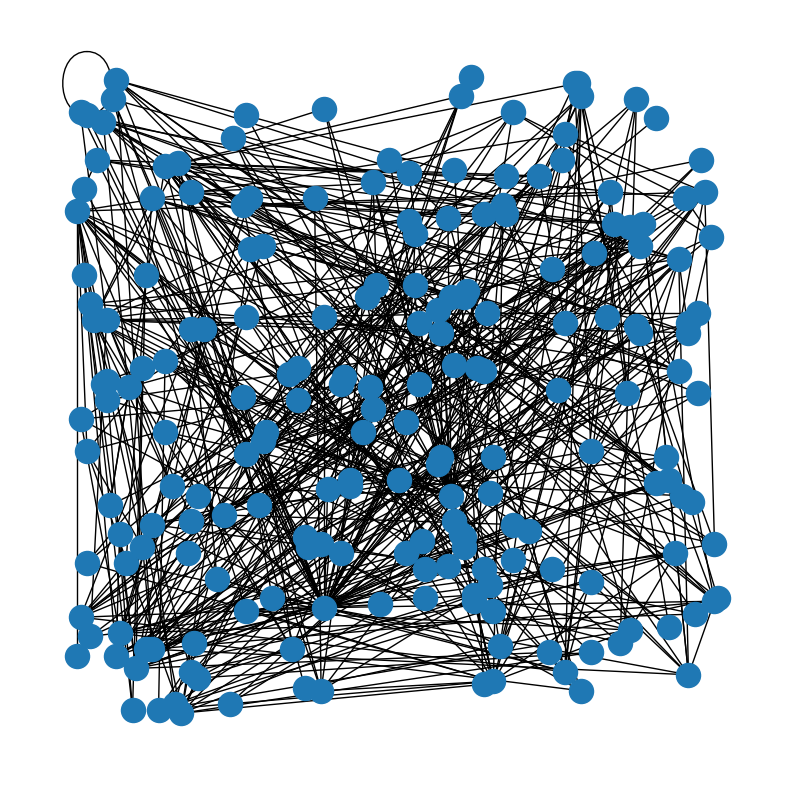

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
nx.draw(H, pos, ax)
plt.show()

Además cada función tiene varios *keywords arguments** para controlar el diseño de los elementos de la red.

Características por vértices:
- ``` alpha  ```: transparencia
- ``` edgecolors  ```: color de borde de vértice
- ``` node_color, node_size, node_shape ```

Para estos parámetros hay dos opciones:
- Un sólo valor (flotante, string, entero): Aplica para todos los vértices
- Un arreglo o lista: Personaliza para cada vértice

Señalar vértices y aristas visibles:
- ```nodelist```
- ```edgelist```

Características por aristas:
- ```width``` Ancho de las aristas
- ``` edge_color, node_size, node_shape ```

In [ ]:
color = ["blue" for i in range(n-50)] + ["red" for i in range(30)]+["green" for i in range(20)]
degrees = [d*30 for n, d in H.degree()]

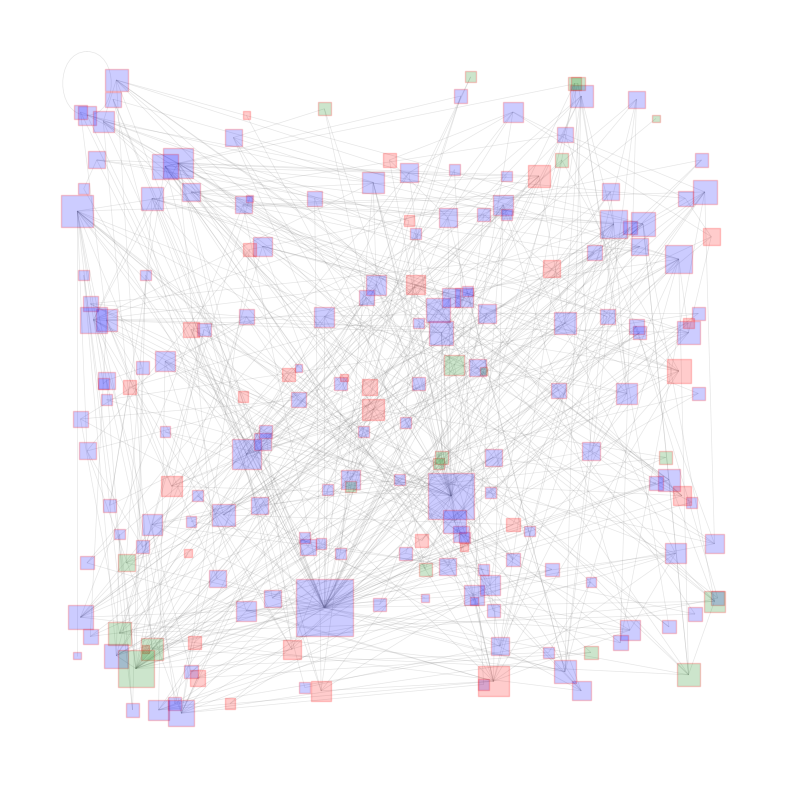

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
nx.draw(H, pos,
        ax=ax,
        alpha=0.2,
        node_color=color,
        edgecolors="red",
        node_size=degrees,
        node_shape="s",
        width=0.5,
        edge_color="gray")
plt.show()

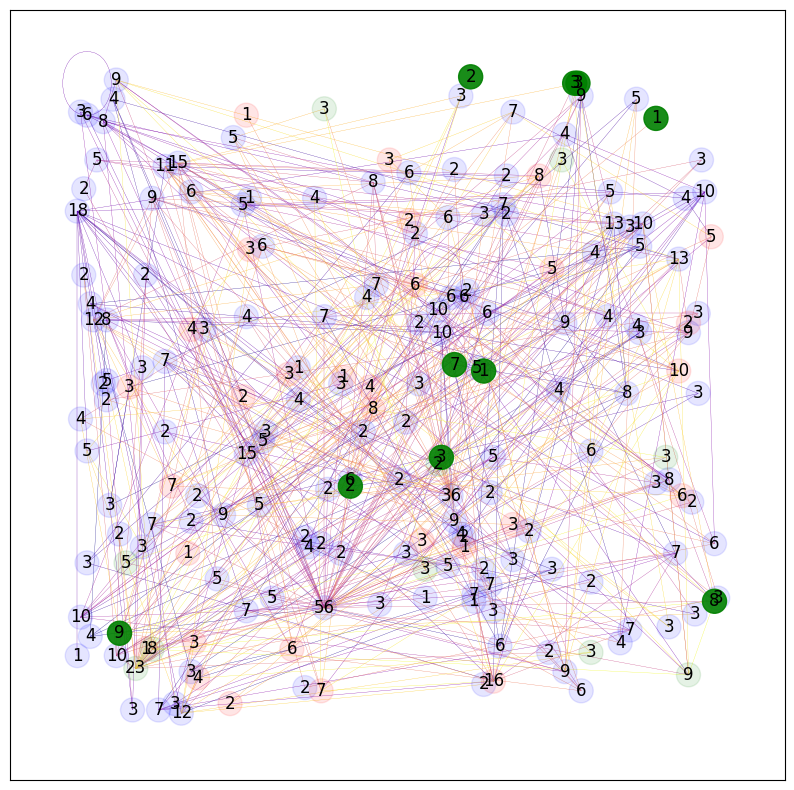

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
alpha = [0.1 for i in range(n-10)] + [.9 for i in range(10)]
M = H.number_of_edges()
edge_colors = list(range(2, M + 2))
cmap = plt.cm.plasma
nx.draw_networkx_nodes(H, pos,
        ax=ax,
        node_color=color,
        alpha=alpha)
nx.draw_networkx_labels(H, pos,
        ax=ax,
        labels=dict(H.degree()))
edges_draw = nx.draw_networkx_edges(H, pos,
            ax=ax,
            edge_color=edge_colors,
            edge_cmap=cmap,
            edge_vmin=min(edge_colors),
            edge_vmax=max(edge_colors),
            width=0.2)
plt.show()

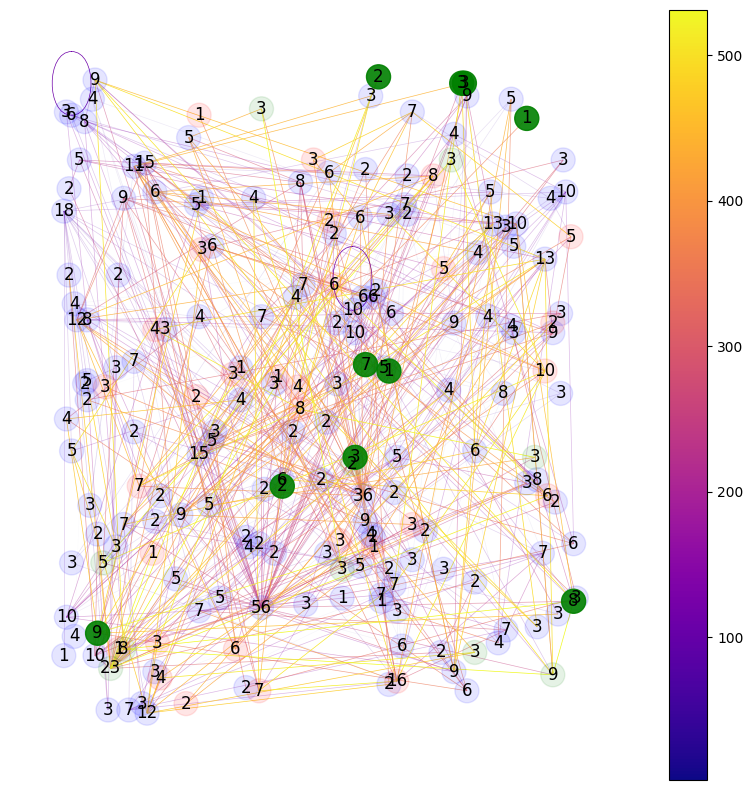

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import networkx as nx

fig, ax = plt.subplots(figsize=(10, 10))

# Suponiendo que G y H están definidos, y pos y color también
# alpha para nodos
alpha = [0.1 for _ in range(H.number_of_nodes() - 10)] + [0.9 for _ in range(10)]

# Colores y alphas para aristas
M = H.number_of_edges()
edge_colors = list(range(2, M + 2))
edge_alphas = [(5 + i) / (M + 4) for i in range(M)]
cmap = plt.cm.plasma

# Dibujar nodos
nx.draw_networkx_nodes(H, pos,
                       ax=ax,
                       node_color=color,
                       alpha=alpha)

# Etiquetas
nx.draw_networkx_labels(H, pos,
                        ax=ax,
                        labels=dict(H.degree()))

# Dibujar aristas con color y mapa de color
edges = nx.draw_networkx_edges(H, pos,
                               ax=ax,
                               edge_color=edge_colors,
                               edge_cmap=cmap,
                               edge_vmin=min(edge_colors),
                               edge_vmax=max(edge_colors),
                               width=0.5)

# Ajustar alpha de cada línea en el LineCollection
if isinstance(edges, mpl.collections.LineCollection):
    edges.set_alpha(edge_alphas)
    edges.set_array(np.array(edge_colors))  # Para la colorbar
    plt.colorbar(edges, ax=ax)

plt.axis('off')
plt.show()

In [ ]:
edge_colors

range(2, 93499)

### **Motores de posición**

Para visualizar una red, se necesita asignar coordenadas a cada nodo. Una opión en Networkx es utilizars motores para generar posiciones específicas.

- ```python
nx.random_layout(G)
```

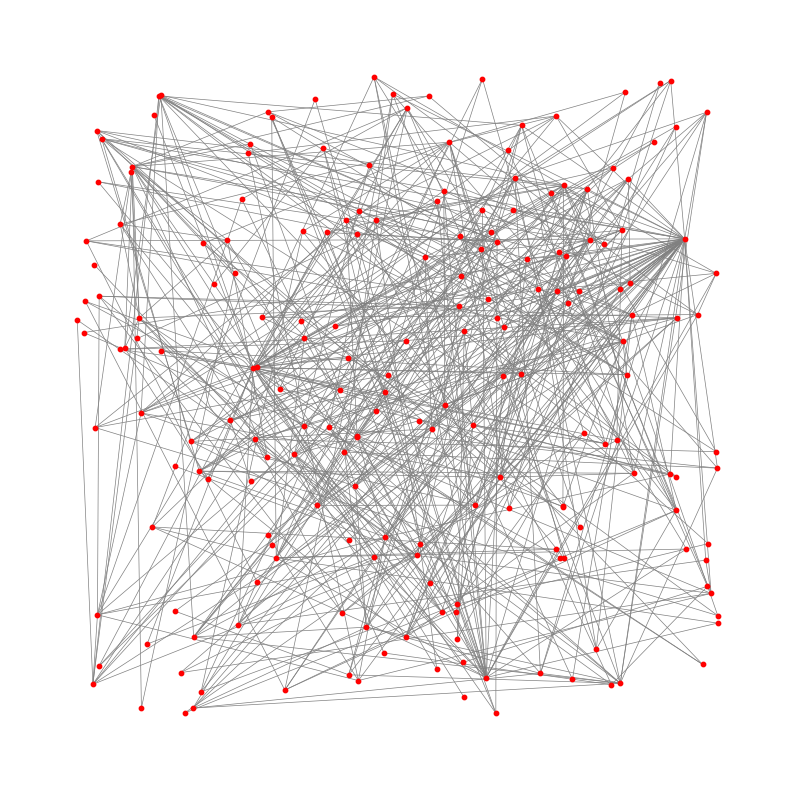

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
pos = nx.random_layout(H)
nx.draw(H, pos, ax,
        node_size=10, node_color="red",
        width=0.5, edge_color="gray")
plt.show()

- ```python
nx.circular_layout(G)
```



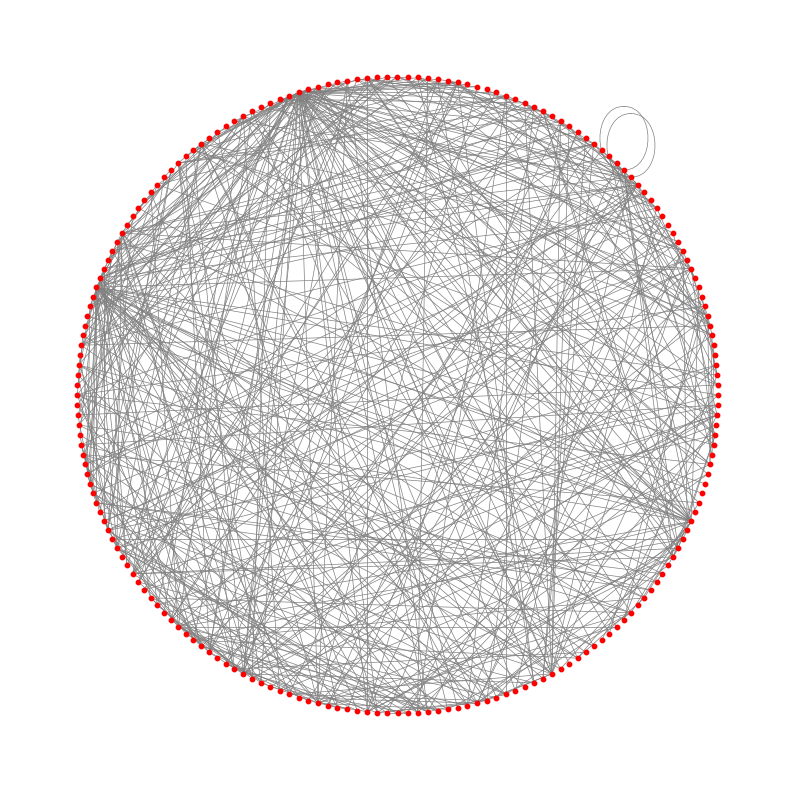

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
pos = nx.circular_layout(H)
nx.draw(H, pos, ax,
        node_size=10, node_color="red",
        width=0.5, edge_color="gray")
plt.show()

- ```python
nx.spring_layout(G, seed=42, k=0.3, iterations=100)
```

Simula una representación de la red basada en fuerzas de repulsión y atracción entre nodos conectados (**modelo de resorte**). La simulación se detiene cuando las posiciones convergen a un punto de equilibrio.

Es ideal para obtener una disposición visualmente informativa.

Parametros:
- ```iterations``` Número máximo de iteraciones en la simulación.
- ```fixed``` Lista de nodos que no son ignorados en la simulación.
- ```k``` Determina la distancia óptima entre los nodos.

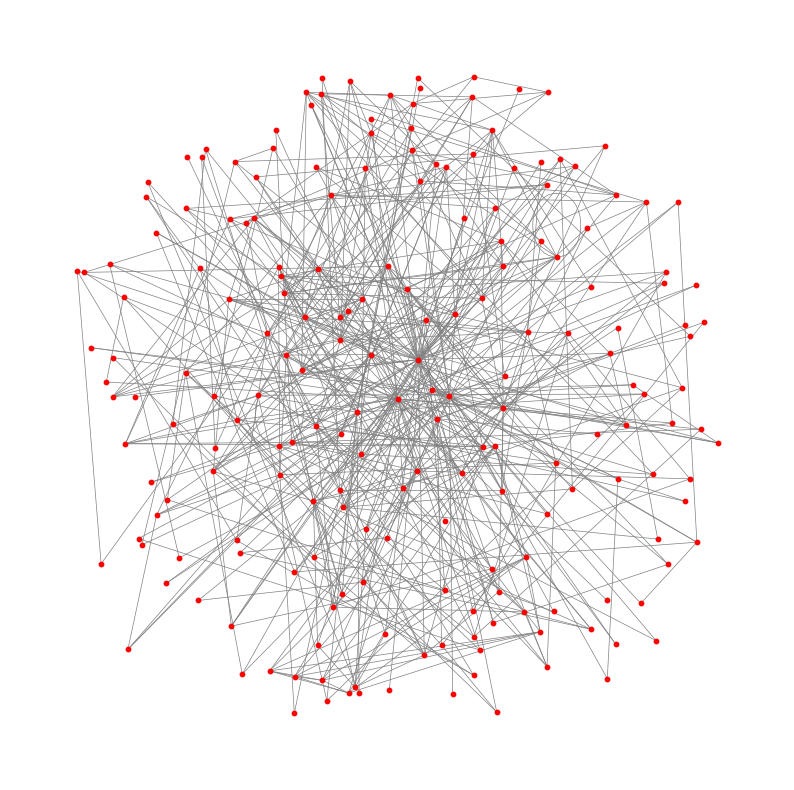

In [ ]:
# 10 iteraciones
fig, ax = plt.subplots(figsize=(10, 10))
pos = nx.spring_layout(H, k=0.3, iterations=10)
nx.draw(H, pos, ax,
        node_size=10, node_color="red",
        width=0.5, edge_color="gray")
plt.show()

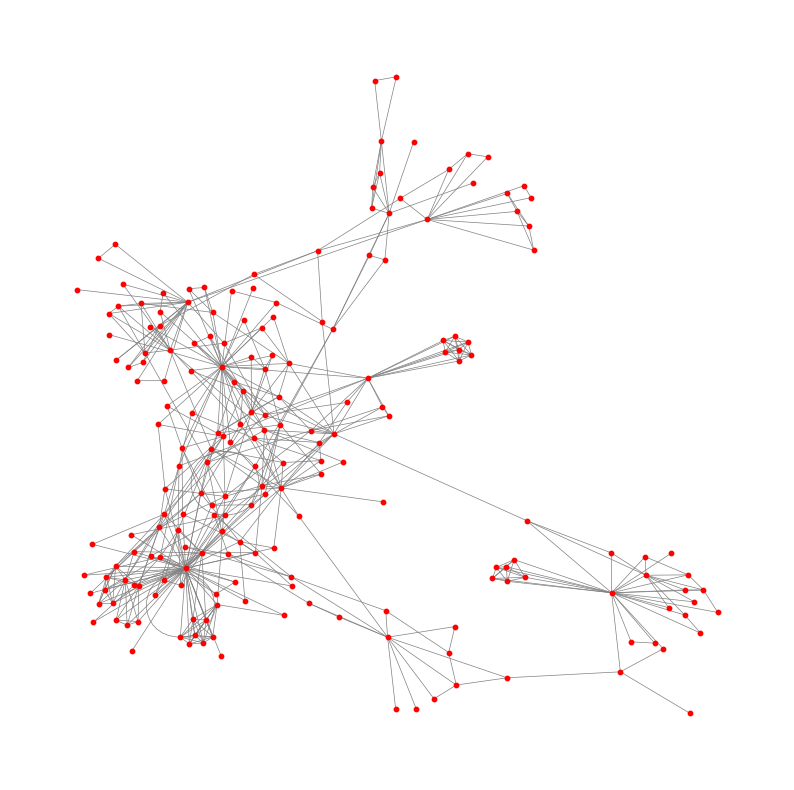

In [ ]:
# 100 iteraciones
fig, ax = plt.subplots(figsize=(10, 10))
pos = nx.spring_layout(H, k=0.3, iterations=100)
nx.draw(H, pos, ax,
        node_size=10, node_color="red",
        width=0.5, edge_color="gray")
plt.show()


- ```python
nx.spectral_layout(H)
```
Usa teoría espectral a la matriz de adyacencia de la gráfica para calcular las posiciones (Vectores propios del laplaciano de la gráfica). Tiende a formar gráficos agrupados en clústeres. Es cosotoso por lo cual no se recomienda para gráficas mayores a 500 nodos.

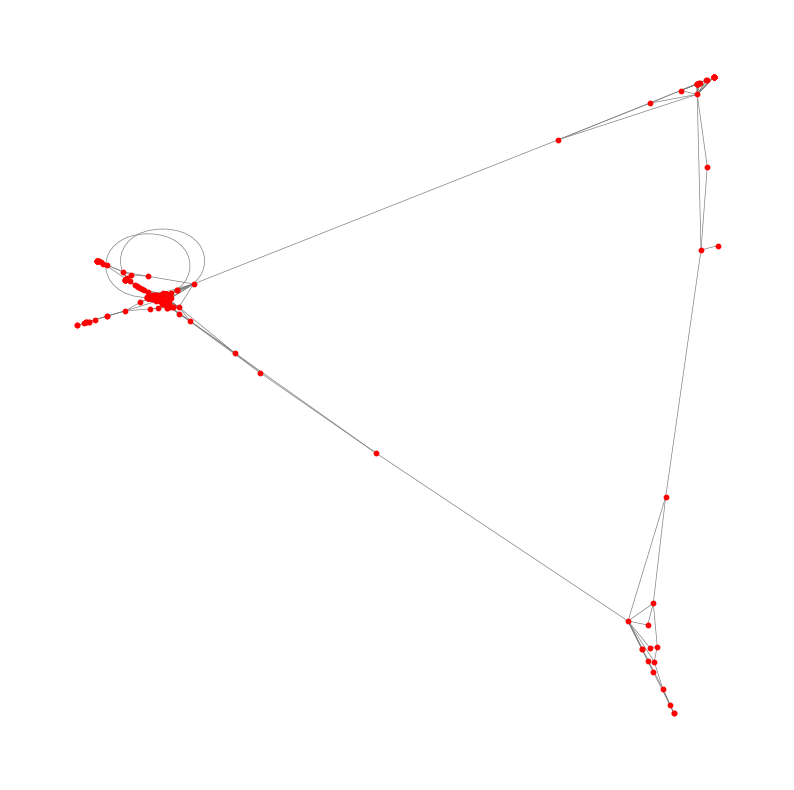

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
pos = nx.spectral_layout(H)
nx.draw(H, pos, ax,
        node_size=10, node_color="red",
        width=0.5, edge_color="gray")
plt.show()


- ```python
nx.shell_layout(G, nlist)
```
Crea posiciones en círculos concentricos.

Parámetros:
  - ```nlist``` Lista de listas con los vértices que pertenecen a cada círculo.

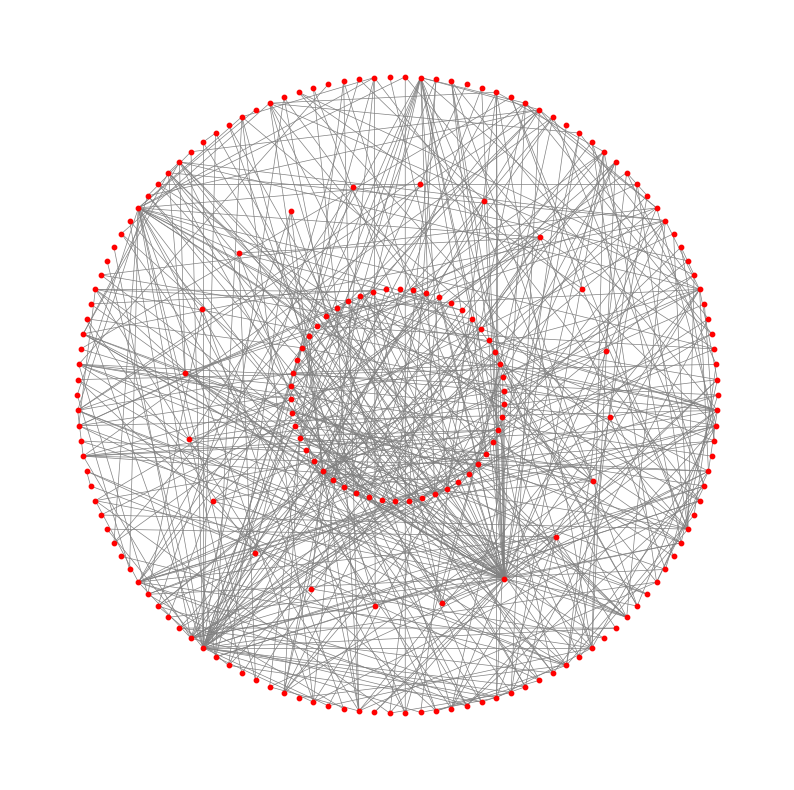

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
nodes = list(H.nodes())
concentric_circles = [nodes[:50],
                      nodes[50:70],
                      nodes[70:]]
pos = nx.shell_layout(H,
                      nlist = concentric_circles)
nx.draw(H, pos, ax,
        node_size=10, node_color="red",
        width=0.5, edge_color="gray")
plt.show()

- ```python
nx.kamada_kawai_layout(G, dist)
```
Crea posiciones basada en una función de costo de longitud de trayectoria [kamada-Kawai](https://www.sciencedirect.com/science/article/abs/pii/0020019089901026?via%3Dihub)

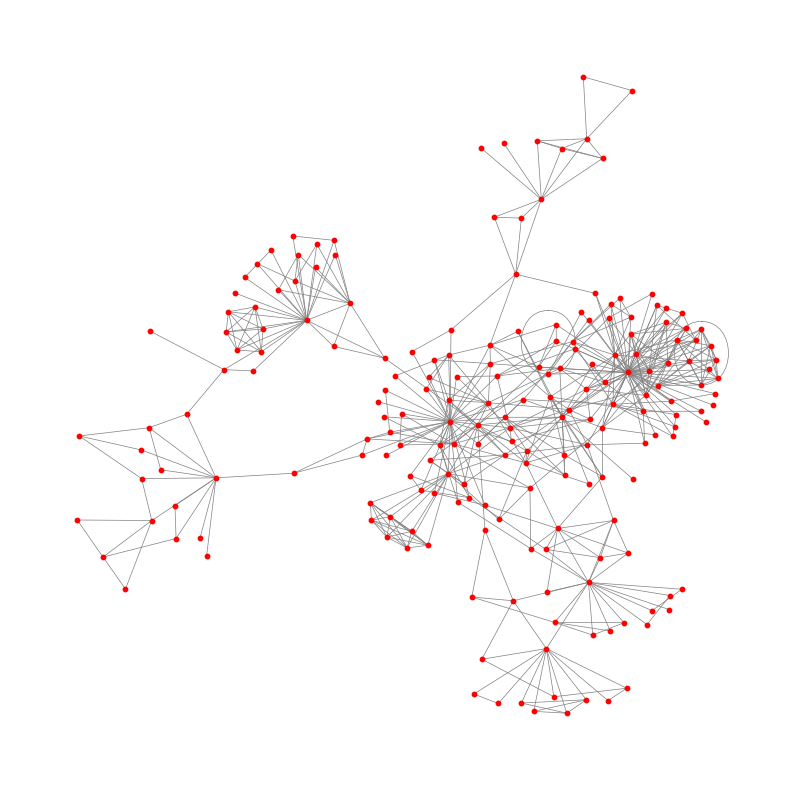

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
pos = nx.kamada_kawai_layout(H)
nx.draw(H, pos, ax,
        node_size=10, node_color="red",
        width=0.5, edge_color="gray")
plt.show()

- ```python
nx.forceatlas2_layout(G, pos, max_iter)
```
Aplica el algoritmo [ForceAtlas2](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0098679) a una red y busca que las posiciones representen la estructura de la red. El algoritmo utiliza simulación inspirada en física para minimizar la energía del sistema.

Parámetros:
- ```max_iter``` Número máximo de iteraciones
- ```gravity``` Controla la fuerza de gravedad.

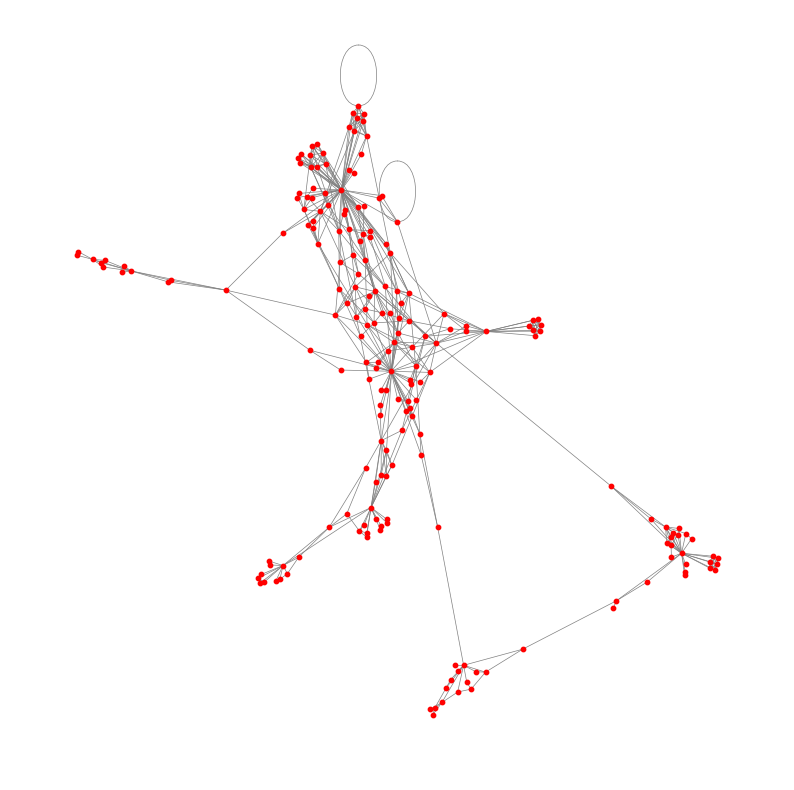

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
pos = nx.forceatlas2_layout(H,
                            max_iter=100,
                            gravity=1,)
nx.draw(H, pos, ax,
        node_size=10, node_color="red",
        width=0.5, edge_color="gray")
plt.show()

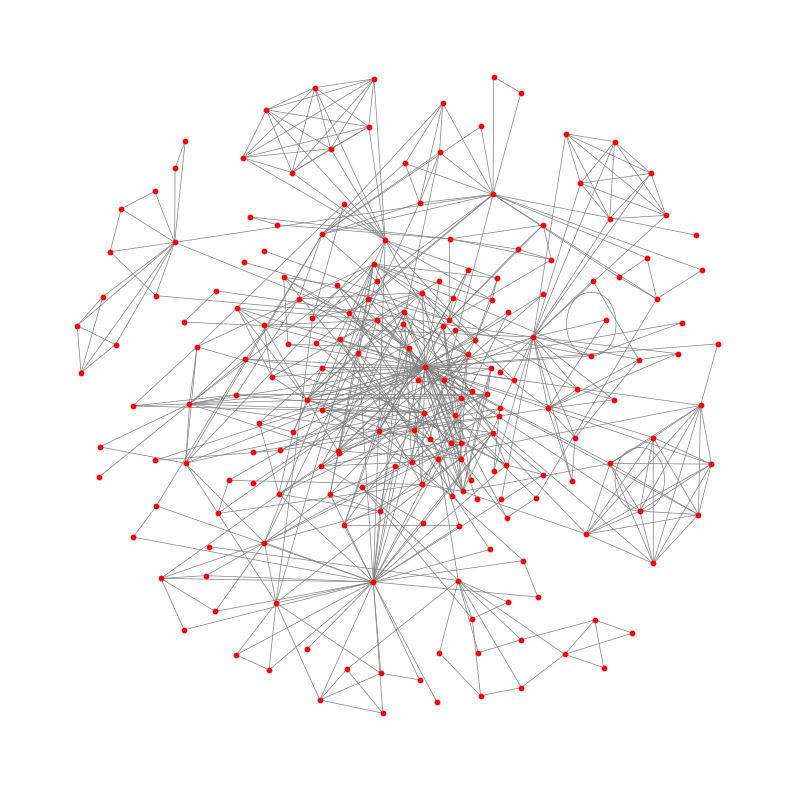

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
pos = nx.forceatlas2_layout(H,
                            max_iter=100,
                            gravity=100)
nx.draw(H, pos, ax,
        node_size=10, node_color="red",
        width=0.5, edge_color="gray")
plt.show()

- ```python
nx.bfs_layout(G, start)
```
Posiciona los vértices de acuerdo a la posición que ocupan en términos de un vértice inicial usando el algoritmo de búsqueda en anchura (**BFS**)

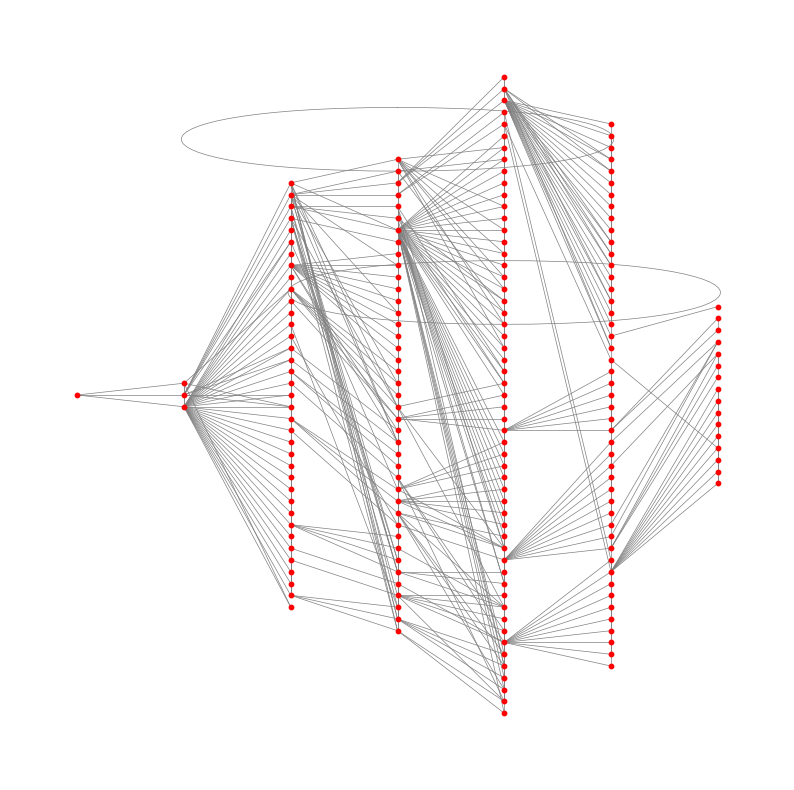

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
node_start = 107009
pos = nx.bfs_layout(H, start=node_start)
nx.draw(H, pos, ax,
        node_size=10, node_color="red",
        width=0.5, edge_color="gray")
plt.show()

- ```python
 nx.spiral_layout(H)
 ```
Posiciona los vétices en torno a una espiral

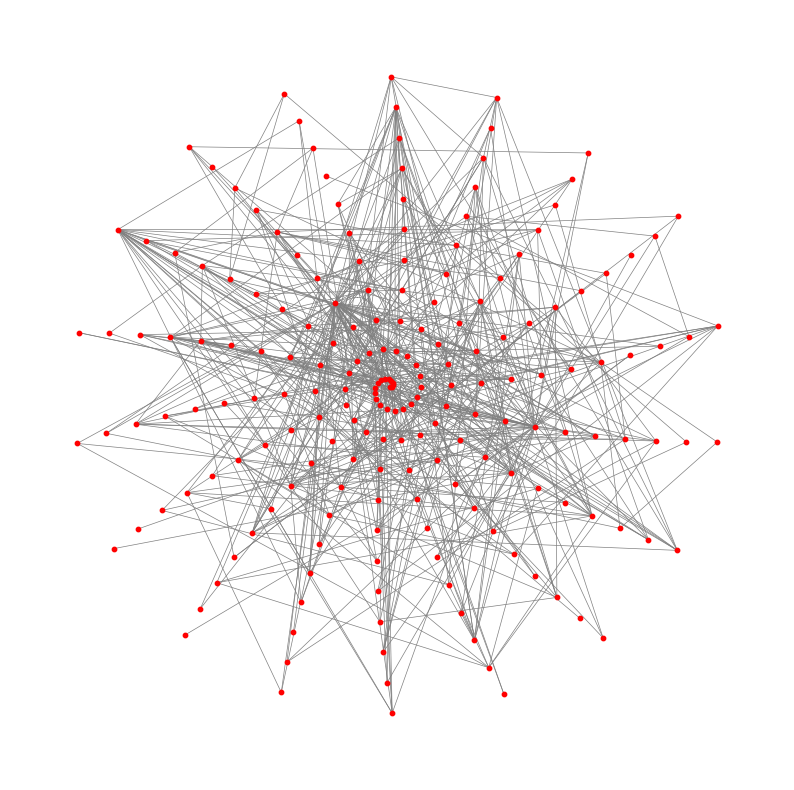

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
pos = nx.spiral_layout(H)
nx.draw(H, pos, ax,
        node_size=10, node_color="red",
        width=0.5, edge_color="gray")
plt.show()

Otros motores:

- ```python
 nx.planar_layout(H)
 ```
 Encuentra una incrustación en el plano (un dibujo de una gráfica sin intersección de aristas) en caso de que la gráfica sea palanar.

- ```python
 nx.bipartite_layout(H)
 ```
 Dada una gráfica bipartita, dibuja los vértices de cada partición en una linea recta.

## **Motores Avanzados (Graphviz)**

- ```python
nx.nx_pydot.pydot_layout(H, prog="dot")
 ```

Herramienta basada en la librería **Graphviz** para generar una disposición jerárquica de los nodos. Esta herramienta permite usar motores de Graphviz como:

- ```dot```: Diseño jerárquico, los nodos se organizan por niveles. ütil para **árboles**, **redes neuronales**
- ```neato```: Usa simulación de fuerzas (semejante a  ```spring_layout ``` de **Networkx**.
- ```fdp```: Similar a  ```neato ```, pero conserva mejor la densidad local. ütil en **redes densas** o con **comunidades**. Tiende a producir formas más compactas.
- ```sfdp```: Versión óptima de  ```fdp ``` para redes grandes, ya que usa técnicas de subdivsión eficientes.
- ```twopi```: Organiza los nodos en anillos concéntricos. Ideal para estructuras cerradas o con jerarquía radial.
- ```circo```: Coloca los nodos en círculos, muy util para ciclos y estructuras simétricas. Es una versión refina de ```nx.circular_layout```

KeyboardInterrupt: 

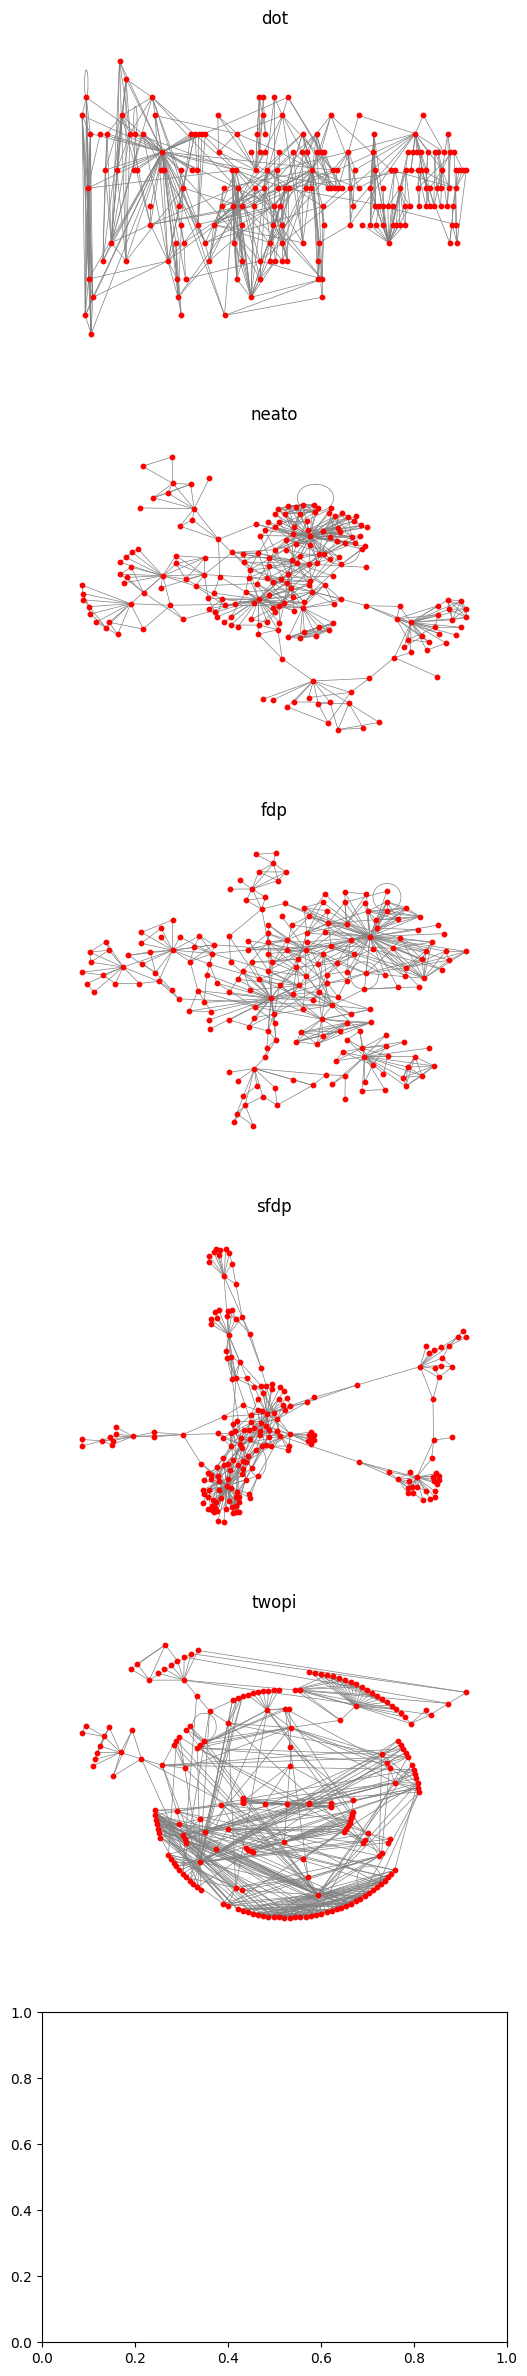

In [ ]:
prog= {0: "dot", 1: "neato", 2: "fdp", 3: "sfdp", 4: "twopi", 5: "circo"}
fig, ax = plt.subplots(6, 1, figsize=(6, 30))
for i in range(6):
  pos = nx.nx_pydot.pydot_layout(H, prog=prog[i])
  nx.draw(H, pos, ax[i],
          node_size=10, node_color="red",
          width=0.5, edge_color="gray")
  ax[i].set_title(prog[i])
plt.show()

El motor  ``` prog="dot" ``` es sumamente útil para representar estructuras de redes neuronales o árboles de decisión

In [ ]:
# Crear red neuronal
NN = nx.DiGraph()
input_layer = [f'I{i}' for i in range(1, 4)]
hidden_layer_1 = [f'H1{i}' for i in range(1, 5)]
hidden_layer_2 = [f'H2{i}' for i in range(1, 6)]
output_layer = [f'O{i}' for i in range(1, 3)]
for i_node in input_layer:
    for h_node in hidden_layer_1:
        NN.add_edge(i_node, h_node)
for h_node in hidden_layer_1:
    for o_node in hidden_layer_2:
        NN.add_edge(h_node, o_node)
for h_node in hidden_layer_2:
  for o_node in output_layer:
      NN.add_edge(h_node, o_node)
# Usar layout jerárquico (pydot con dot)
pos = nx.nx_pydot.pydot_layout(NN, prog="dot")
fig, ax = plt.subplots(figsize=(10, 6))
nx.draw(NN, pos,
        with_labels=True,
        arrows=True,
        node_size=1500,
        node_color='lightblue',
        edge_color='gray',
        ax=ax)
plt.show()

In [ ]:
# Crear árbol de decisión
T = nx.DiGraph()
T.add_edges_from([
    ("Inicio", "Evaluar datos"),
    ("Evaluar datos", "Aplicar modelo A"),
    ("Evaluar datos", "Aplicar modelo B"),
    ("Aplicar modelo A", "Resultado A1"),
    ("Aplicar modelo A", "Resultado A2"),
    ("Aplicar modelo B", "Resultado B1"),
    ("Aplicar modelo B", "Resultado B2"),
])

# Usar pydot_layout para una disposición jerárquica
pos = nx.nx_pydot.pydot_layout(T, prog="dot")
fig, ax = plt.subplots(figsize=(10, 6))
nx.draw(T, pos,
        ax=ax,
        with_labels=True,
        arrows=True,
        node_size=1500,
        node_color='lightyellow',
        edge_color='gray',)
plt.show()